In [9]:
import sys
import os

# this is needed only if maboss is not seen by Jupyter
path_dev = os.path.expanduser("/")
if path_dev not in sys.path:
    sys.path.insert(0, path_dev)

import maboss
from maboss import temporal_logic as tl


# Step 1 - Préparer les questions

Dans cette version de pyMaBoSS, toutes les simulations sont effectuées automatiquement.
Je vais utiliser les fichiers de configurations du BRAF pour faire la démonstration

Les questions doivent être un tableau de `string`, voilà les questions auxquelles on va répondre à travers cette démo :
- A quel(s) moment(s) la probabilité du node **AKT** est-elle supérieure à 0.4 ?
- A quel(s) moment(s) la probabilité du node **AKT** est-elle supérieure à 0.4 sachant que **BRAF** ET **Proliferation_b2** sont actifs aussi ?
- La première période de temps durant laquelle la probabilité de **MDM2** est supérieur ou égale à 0.7.
- Toutes les périodes où la probabilité de **p53** est supérieure à 0.5
## Voilà pour les assertions faciles à comprendre. Voici une vraie assertion qui implique une mutation, également gérée par la boucle.
- L'induction du chemin **PI3K-AKT** est associé à une diminution de la sensibilité de **MAPK** à l'inhibition. (Dans le programme **MAPK** est représenté par **Proliferation_b1** et **Proliferation_b2**)

In [10]:
assertions_list = [
    "P(node:AKT) > 0.4",
    "P(node:AKT) > 0.4 [ node:BRAF & node:Proliferation_b2 ]",
    "Tmin(node:MDM2) >= 0.1",
    "T(node:p53) < 0.5",
    "Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ PI3K:ON BRAF:ON ]"
]

## On enregistre les fichiers pour que ce soit plus facile

In [11]:
#Fichiers de config
file_bnd = "BRAF_Model.bnd"
file_cfg = "BRAF_Model.cfg"

## Puis on lance le programme

In [12]:
res = tl.evaluator.MaBoSSEvaluator.querying(assertions_list, file_bnd, file_cfg)

query : P(node:AKT) > 0.4
query : P(node:AKT) > 0.4 [ node:BRAF & node:Proliferation_b2 ]
query : Tmin(node:MDM2) >= 0.1
query : T(node:p53) < 0.5
query : Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ PI3K:ON BRAF:ON ]


In [16]:
print("Taille de res : ", len(res), "")
i=0
for r in res:
    print(f"Assertion : {assertions_list[i]}\n")
    display(r)
    i+=1
print(res[4])

Taille de res :  5 
Assertion : P(node:AKT) > 0.4



,Time,AKT
0,0.0,0.505030
1,0.5,0.503276
2,1.0,0.503002
3,1.5,0.490515
4,2.0,0.477470
5,2.5,0.472595
6,3.0,0.461888
7,3.5,0.448549
8,4.0,0.436399
9,4.5,0.427316


Assertion : P(node:AKT) > 0.4 [ node:BRAF & node:Proliferation_b2 ]



,Time,AKT,BRAF,Proliferation_b2
0,0.0,0.505030,0.449150,0.398982
1,0.5,0.503276,0.368029,0.261693
2,1.0,0.503002,0.308978,0.191123
3,1.5,0.490515,0.267610,0.151019
4,2.0,0.477470,0.231254,0.129880
5,2.5,0.472595,0.209320,0.118889
6,3.0,0.461888,0.196290,0.117626
7,3.5,0.448549,0.185260,0.118805
8,4.0,0.436399,0.176630,0.116312
9,4.5,0.427316,0.166460,0.112714


Assertion : Tmin(node:MDM2) >= 0.1



...

Assertion : T(node:p53) < 0.5



,Time,p53
0,0.0,0.451494
1,0.5,0.399516
2,1.0,0.402342
3,1.5,0.419166
4,2.0,0.436925
...,...,...
95,47.5,0.492997
96,48.0,0.493013
97,48.5,0.493015
98,49.0,0.493002


Assertion : Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ PI3K:ON BRAF:ON ]



,Proliferation_b1 from master,Proliferation_b1 from mutation,Difference Proliferation_b1,Percentage Proliferation_b1,Increase Proliferation_b1,Proliferation_b2 from master,Proliferation_b2 from mutation,Difference Proliferation_b2,Percentage Proliferation_b2,Increase Proliferation_b2
0,0.237061,1.0,0.762939,321.83%,True,0.133936,1.0,0.866064,646.63%,True


   Proliferation_b1 from master  Proliferation_b1 from mutation  \
0                      0.237061                             1.0   

   Difference Proliferation_b1 Percentage Proliferation_b1  \
0                     0.762939                     321.83%   

   Increase Proliferation_b1  Proliferation_b2 from master  \
0                       True                      0.133936   

   Proliferation_b2 from mutation  Difference Proliferation_b2  \
0                             1.0                     0.866064   

  Percentage Proliferation_b2  Increase Proliferation_b2  
0                     646.63%                       True  


### On peut afficher les résultats sous forme de courbe en fonction du temps
Prenons l'assertion `T(node:p53) < 0.5`

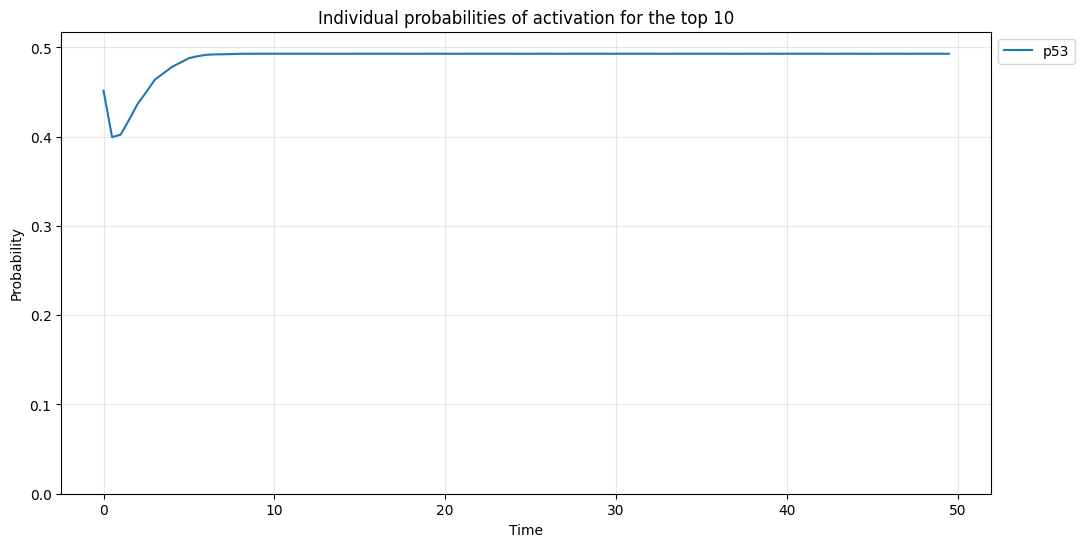

In [14]:
viz = tl.Visualiser(res[3])
viz.evolution_over_time()

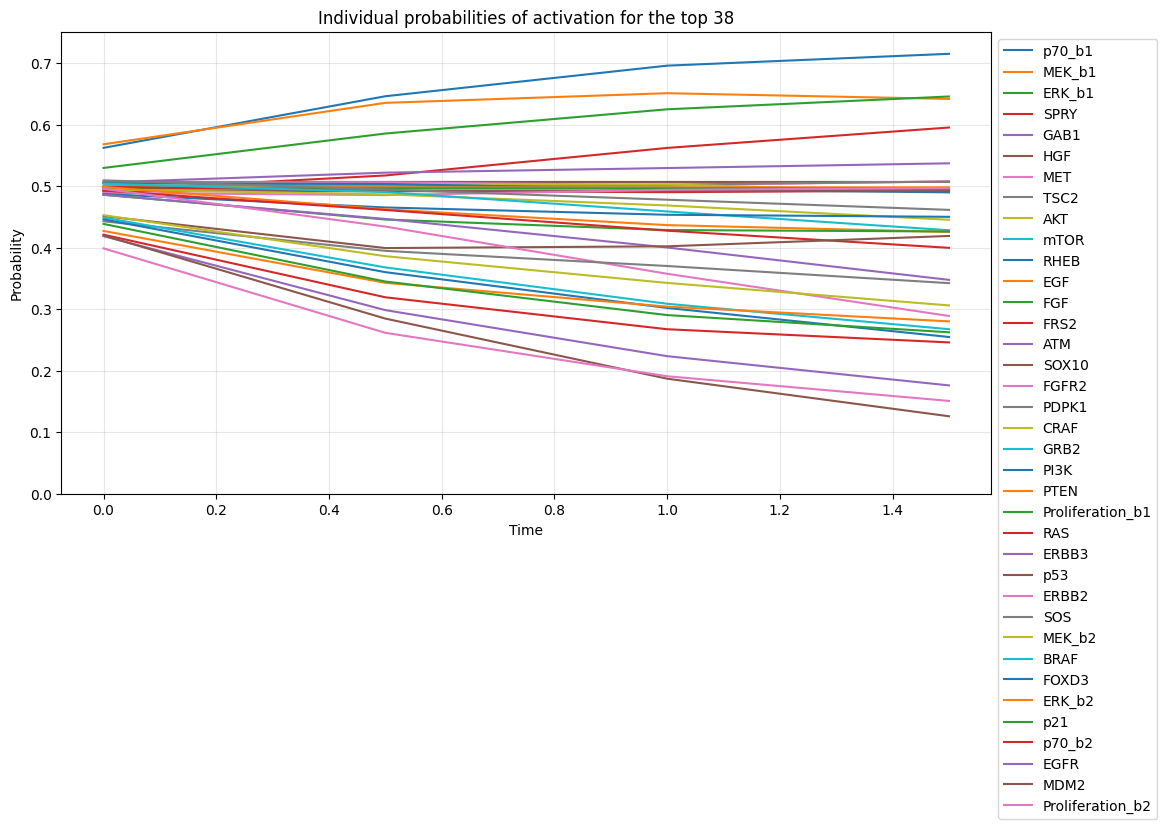

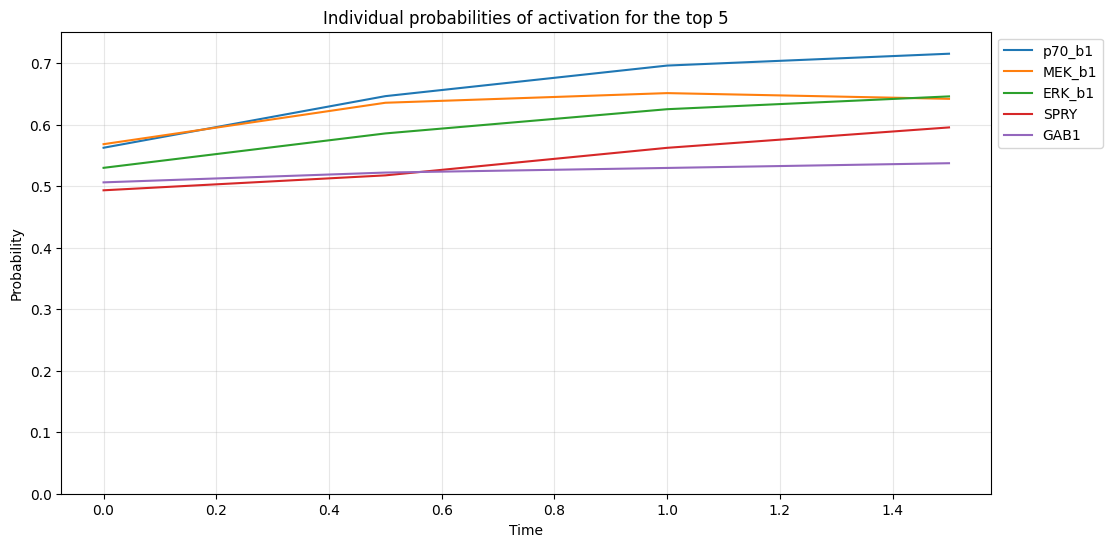

In [15]:
viz_mdm2 = tl.Visualiser(res[2])
viz_mdm2.evolution_over_time(len(res[2].columns))
viz_mdm2.evolution_over_time(5)

In [4]:
import maboss
model_sim = maboss.load("BRAF_Model.bnd", "BRAF_Model.cfg")
res_model = model_sim.run()
display(res_model.get_fptable())

,FP,Proba,State,p53,PTEN,PDPK1,AKT,PI3K,p70_b1,mTOR,p70_b2,ERK_b1,MEK_b1,ERK_b2,MEK_b2,Proliferation_b1,Proliferation_b2,p21,BRAF,CRAF,RAS,SOS,GRB2,SPRY,EGFR,MET,FRS2,ERBB3,GAB1,EGF,FOXD3,HGF,FGF,FGFR2,TSC2,RHEB,SOX10,ERBB2,ATM,MDM2
0,#1,0.0312,p53 -- PTEN -- p21 -- TSC2 -- ATM,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,#2,0.0314,TSC2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
